In [40]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("C:/Users/preet/Desktop/ML/Datasets/taxi_trip_pricing_ttp.csv")
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [4]:
for i in ["Trip_Distance_km","Passenger_Count","Base_Fare","Per_Km_Rate","Per_Minute_Rate","Trip_Duration_Minutes","Trip_Price"]:
    df[i] = df[i].fillna(df[i].median())

In [5]:
for i in ["Time_of_Day","Day_of_Week","Weather","Traffic_Conditions"]:
    df[i] = df[i].fillna(df[i].mode()[0])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   object 
 2   Day_of_Week            1000 non-null   object 
 3   Passenger_Count        1000 non-null   float64
 4   Traffic_Conditions     1000 non-null   object 
 5   Weather                1000 non-null   object 
 6   Base_Fare              1000 non-null   float64
 7   Per_Km_Rate            1000 non-null   float64
 8   Per_Minute_Rate        1000 non-null   float64
 9   Trip_Duration_Minutes  1000 non-null   float64
 10  Trip_Price             1000 non-null   float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,3.52,0.62,0.43,40.57,50.0745
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,Clear,3.48,0.51,0.15,116.81,36.4698
4,25.83,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [9]:
df.corr(numeric_only=True)["Trip_Price"]

Trip_Distance_km         0.830479
Passenger_Count         -0.012468
Base_Fare                0.033103
Per_Km_Rate              0.256122
Per_Minute_Rate          0.131534
Trip_Duration_Minutes    0.214669
Trip_Price               1.000000
Name: Trip_Price, dtype: float64

Here on Trip Distance KM has strong relation with trip price other columns have weak and no relation.

<Axes: xlabel='Trip_Distance_km', ylabel='Trip_Price'>

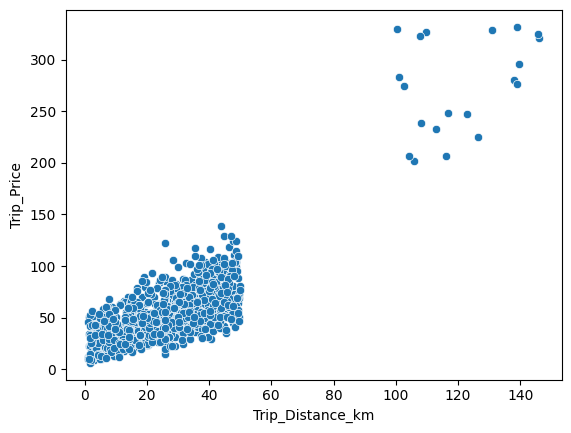

In [10]:
sns.scatterplot(df, x = "Trip_Distance_km", y = "Trip_Price")

<Axes: xlabel='Time_of_Day', ylabel='Trip_Price'>

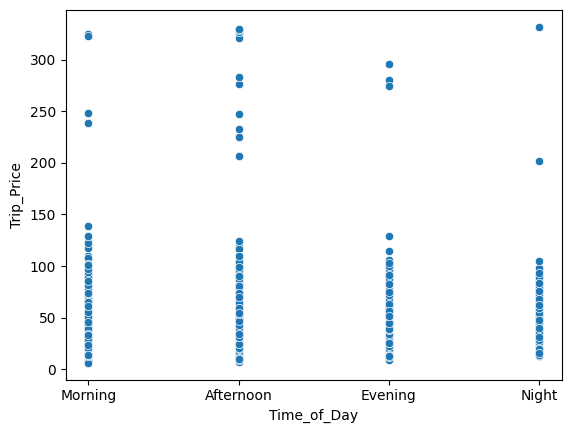

In [11]:
sns.scatterplot(df, x = "Time_of_Day", y = "Trip_Price")

<Axes: xlabel='Day_of_Week', ylabel='Trip_Price'>

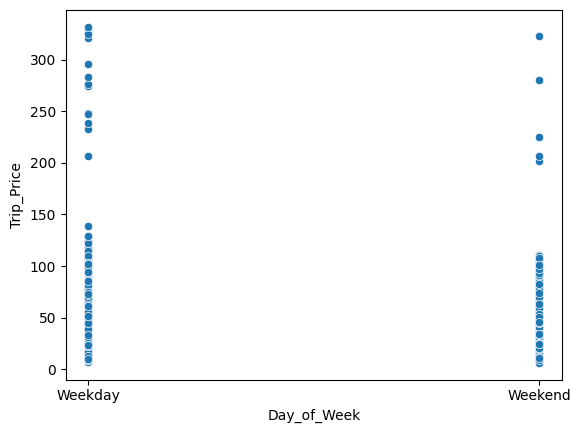

In [12]:
sns.scatterplot(df, x = "Day_of_Week", y = "Trip_Price")

<Axes: xlabel='Passenger_Count', ylabel='Trip_Price'>

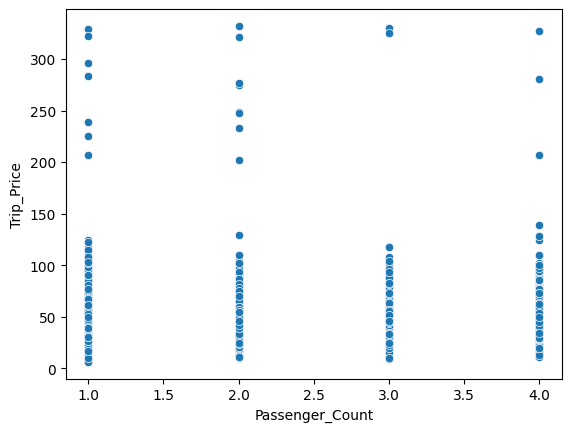

In [13]:
sns.scatterplot(df, x = "Passenger_Count", y = "Trip_Price")

<Axes: xlabel='Traffic_Conditions', ylabel='Trip_Price'>

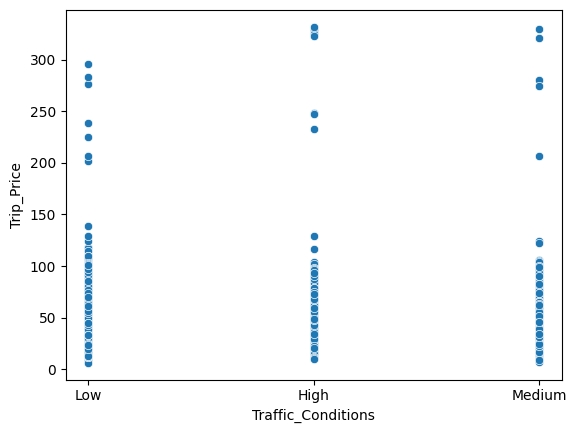

In [14]:
sns.scatterplot(df, x = "Traffic_Conditions", y = "Trip_Price")

<Axes: xlabel='Weather', ylabel='Trip_Price'>

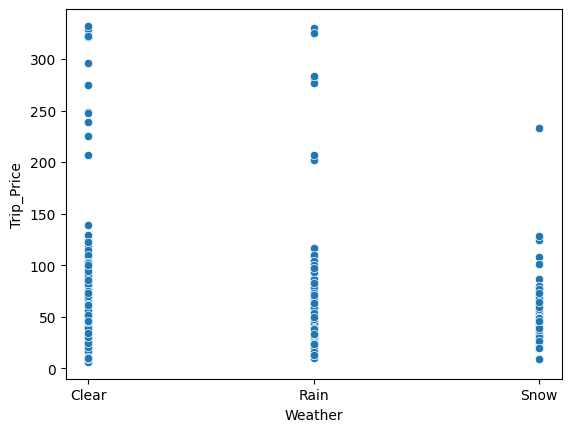

In [15]:
sns.scatterplot(df, x = "Weather", y = "Trip_Price")

<Axes: xlabel='Base_Fare', ylabel='Trip_Price'>

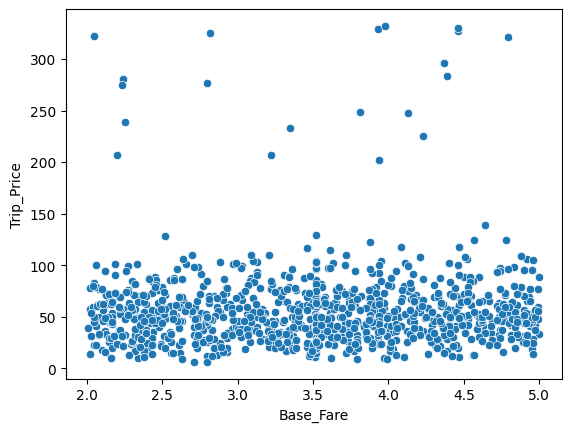

In [16]:
sns.scatterplot(df, x = "Base_Fare", y = "Trip_Price")

<Axes: xlabel='Per_Km_Rate', ylabel='Trip_Price'>

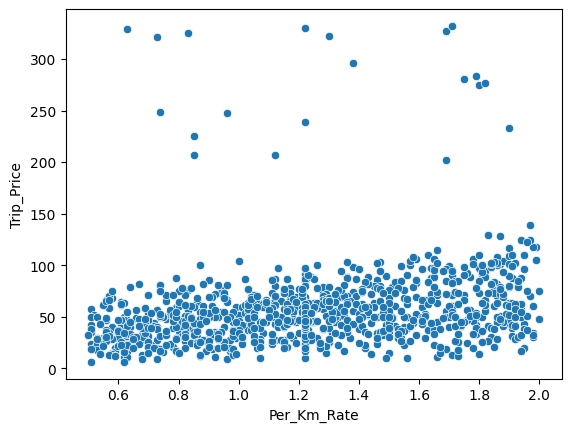

In [17]:
sns.scatterplot(df, x = "Per_Km_Rate", y = "Trip_Price")

<Axes: xlabel='Per_Minute_Rate', ylabel='Trip_Price'>

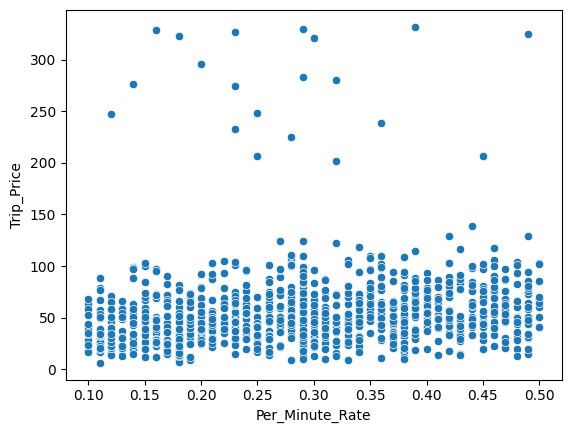

In [18]:
sns.scatterplot(df, x = "Per_Minute_Rate", y = "Trip_Price")

<Axes: xlabel='Trip_Duration_Minutes', ylabel='Trip_Price'>

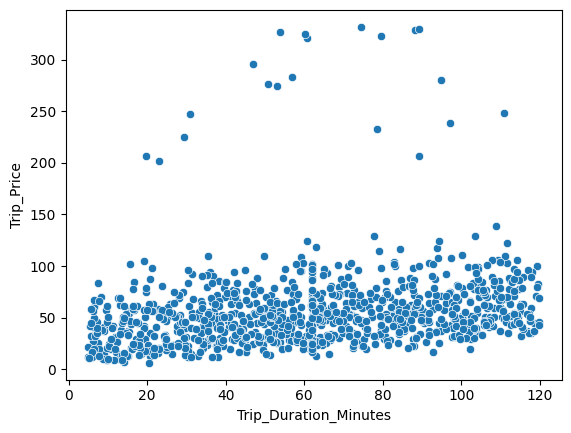

In [19]:
sns.scatterplot(df, x = "Trip_Duration_Minutes", y = "Trip_Price")

In [20]:
print(df["Time_of_Day"].unique())
print(df["Day_of_Week"].unique())
print(df["Traffic_Conditions"].unique())
print(df["Weather"].unique())

['Morning' 'Afternoon' 'Evening' 'Night']
['Weekday' 'Weekend']
['Low' 'High' 'Medium']
['Clear' 'Rain' 'Snow']


In [21]:
df["Time_of_Day"] = df["Time_of_Day"].replace({"Morning" : 0, "Afternoon" : 1, "Evening" : 2, "Night" : 3})
df["Day_of_Week"] = df["Day_of_Week"].replace({"Weekday" : 0, "Weekend" : 1})
df["Traffic_Conditions"] = df["Traffic_Conditions"].replace({"Low" : 0,"Medium" : 1, "High" : 2})
df["Weather"] = df["Weather"].replace({"Clear" : 0, "Rain" : 1, "Snow" : 2})

C:\Users\preet\AppData\Local\Temp\ipykernel_6620\2441868140.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Time_of_Day"] = df["Time_of_Day"].replace({"Morning" : 0, "Afternoon" : 1, "Evening" : 2, "Night" : 3})
C:\Users\preet\AppData\Local\Temp\ipykernel_6620\2441868140.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Day_of_Week"] = df["Day_of_Week"].replace({"Weekday" : 0, "Weekend" : 1})
C:\Users\preet\AppData\Local\Temp\ipykernel_6620\2441868140.py:3: FutureWarning: Downcasting behavior in `replace` is deprecat

In [22]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,0,0,3.0,0,0,3.56,0.80,0.32,53.82,36.2624
1,47.59,1,0,1.0,2,0,3.52,0.62,0.43,40.57,50.0745
2,36.87,2,1,1.0,2,0,2.70,1.21,0.15,37.27,52.9032
3,30.33,2,0,4.0,0,0,3.48,0.51,0.15,116.81,36.4698
4,25.83,2,0,3.0,2,0,2.93,0.63,0.32,22.64,15.6180


In [23]:
x = df.drop("Trip_Price", axis = 1)
y = df["Trip_Price"]

In [24]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, train_size=0.8, random_state=42)

In [25]:
model = LinearRegression()

In [26]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
ypred = model.predict(xtrain)

In [41]:
mse = mean_squared_error(ytrain, ypred)
mse

272.6703417282648

In [42]:
mae = mean_absolute_error(ytrain,ypred)
mae

10.679747907683495

In [43]:
rmse = root_mean_squared_error(ytrain,ypred)
rmse

16.51273271534015

In [44]:
print(f"MAE : {mae}")
print(f"RMSE : {rmse}")

MAE : 10.679747907683495
RMSE : 16.51273271534015


Here the difference between mae and rmse is low model prediction must be good.

In [45]:
r2 = r2_score(ytrain,ypred)
r2

0.8431166238301431

In [28]:
(model.score(xtrain, ytrain))*100

84.31166238301431

Here r2_score is 84% so the model prediction is good.

In [29]:
xtrain.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes'],
      dtype='object')

<Axes: xlabel='Trip_Distance_km', ylabel='Trip_Price'>

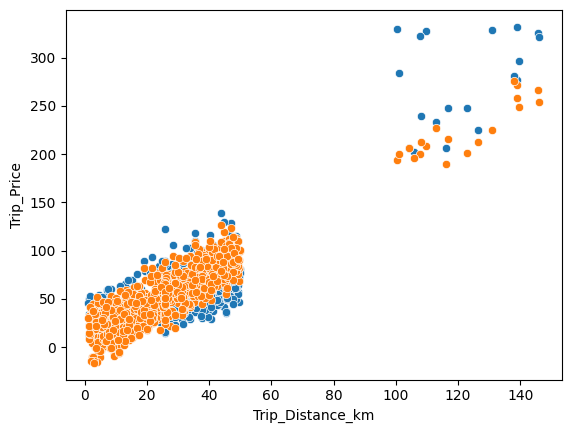

In [30]:
sns.scatterplot(x = xtrain["Trip_Distance_km"], y = ytrain)
sns.scatterplot(x = xtrain["Trip_Distance_km"], y = ypred)

<Axes: xlabel='Time_of_Day', ylabel='Trip_Price'>

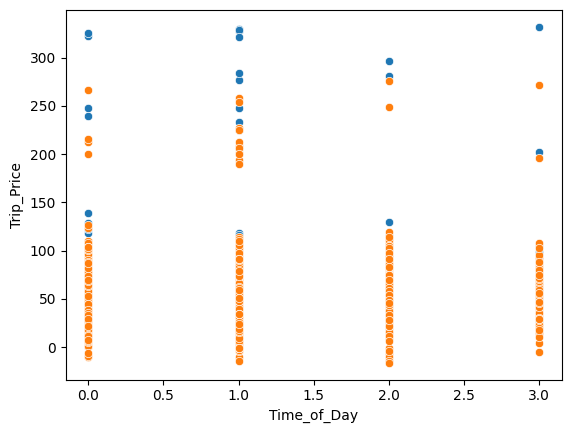

In [31]:
sns.scatterplot(x = xtrain["Time_of_Day"], y = ytrain)
sns.scatterplot(x = xtrain["Time_of_Day"], y = ypred)

<Axes: xlabel='Day_of_Week', ylabel='Trip_Price'>

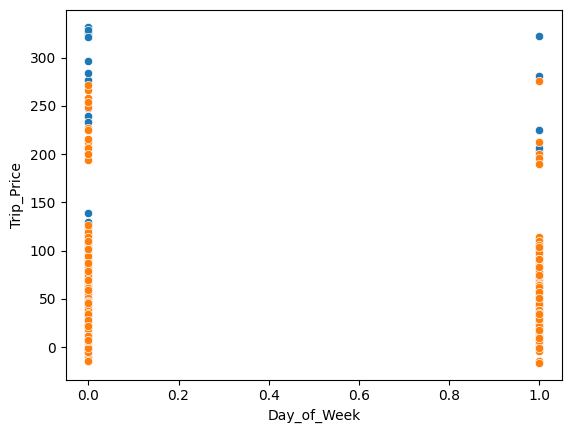

In [32]:
sns.scatterplot(x = xtrain["Day_of_Week"], y = ytrain)
sns.scatterplot(x = xtrain["Day_of_Week"], y = ypred)

<Axes: xlabel='Passenger_Count', ylabel='Trip_Price'>

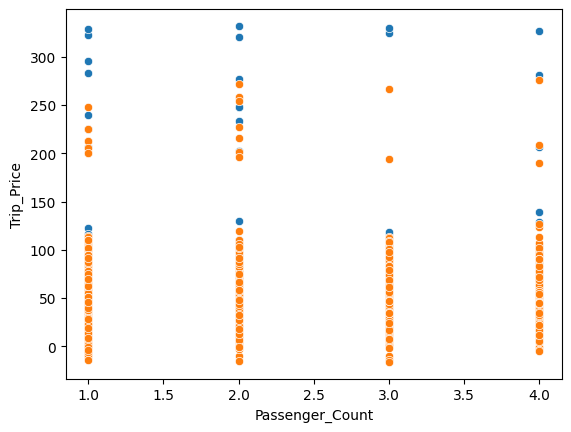

In [33]:
sns.scatterplot(x = xtrain["Passenger_Count"], y = ytrain)
sns.scatterplot(x = xtrain["Passenger_Count"], y = ypred)

<Axes: xlabel='Traffic_Conditions', ylabel='Trip_Price'>

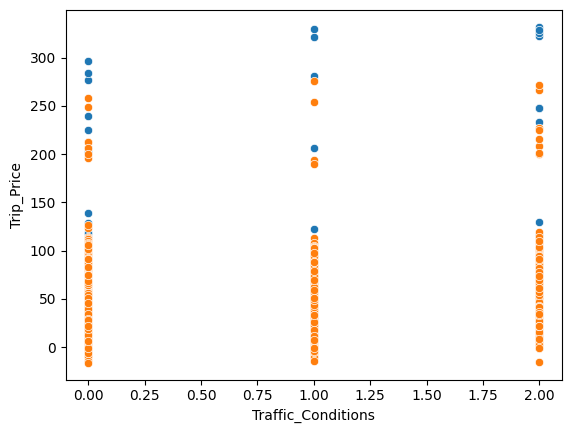

In [34]:
sns.scatterplot(x = xtrain["Traffic_Conditions"], y = ytrain)
sns.scatterplot(x = xtrain["Traffic_Conditions"], y = ypred)

<Axes: xlabel='Weather', ylabel='Trip_Price'>

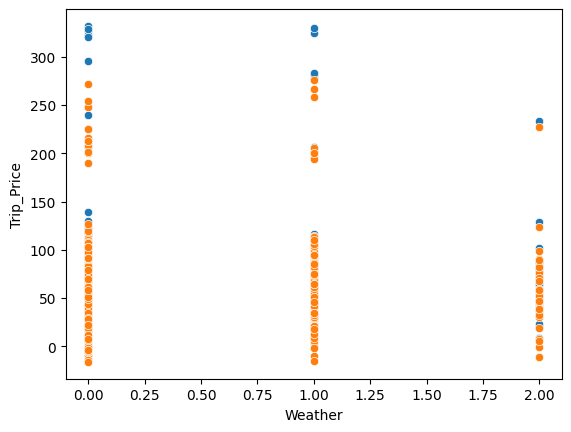

In [35]:
sns.scatterplot(x = xtrain["Weather"], y = ytrain)
sns.scatterplot(x = xtrain["Weather"], y = ypred)

<Axes: xlabel='Base_Fare', ylabel='Trip_Price'>

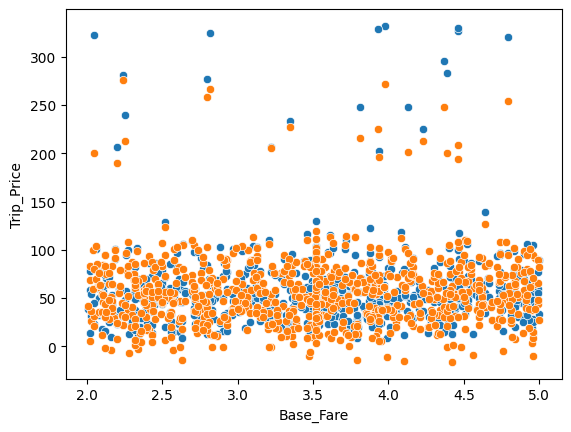

In [36]:
sns.scatterplot(x = xtrain["Base_Fare"], y = ytrain)
sns.scatterplot(x = xtrain["Base_Fare"], y = ypred)

<Axes: xlabel='Per_Km_Rate', ylabel='Trip_Price'>

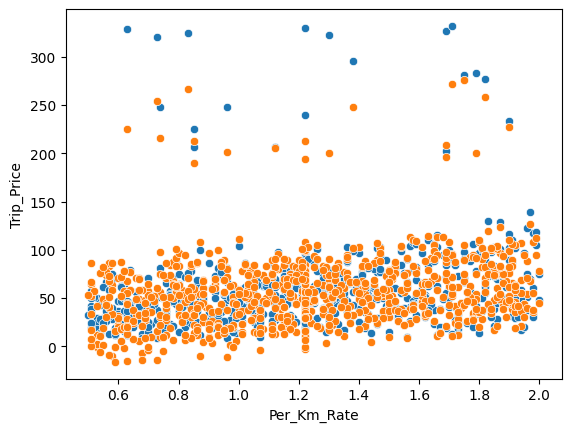

In [37]:
sns.scatterplot(x = xtrain["Per_Km_Rate"], y = ytrain)
sns.scatterplot(x = xtrain["Per_Km_Rate"], y = ypred)

<Axes: xlabel='Per_Minute_Rate', ylabel='Trip_Price'>

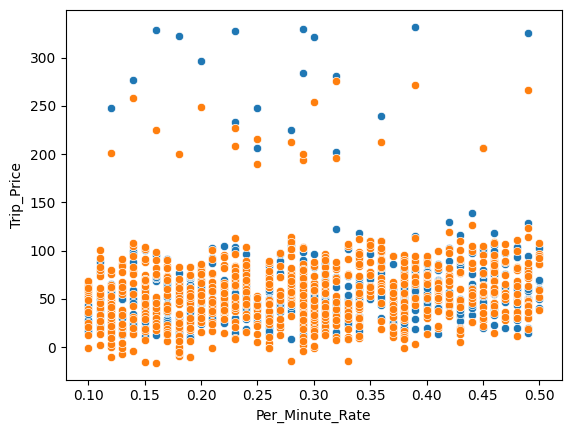

In [38]:
sns.scatterplot(x = xtrain["Per_Minute_Rate"], y = ytrain)
sns.scatterplot(x = xtrain["Per_Minute_Rate"], y = ypred)

<Axes: xlabel='Trip_Duration_Minutes', ylabel='Trip_Price'>

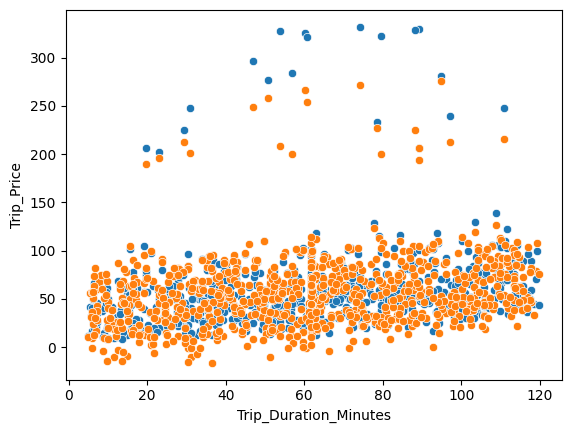

In [39]:
sns.scatterplot(x = xtrain["Trip_Duration_Minutes"], y = ytrain)
sns.scatterplot(x = xtrain["Trip_Duration_Minutes"], y = ypred)

By evaluating this plots we can say that error is low so the model prediction is good.